# **Chuẩn bị thư viện**

In [ ]:
pip install seaborn #Cài đặt thư viện seaborn

In [ ]:
import seaborn as sns #Import thư viện Seaborn

In [ ]:
# Ignore warnings
import warnings
warnings.simplefilter(action = "ignore", category = FutureWarning)

In [ ]:
# Import library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# **Import data**

In [ ]:
import pandas as pd
stations = {
    "1": "https://docs.google.com/spreadsheets/d/14LUFKf7SYmL6q49kLJPPSQIwA8znCXgS/export?format=xlsx",
    "2": "https://docs.google.com/spreadsheets/d/1Ujovs5f3MYPFTp1GUQpqAel0ASU7hvCQ/export?format=xlsx",
    "3": "https://docs.google.com/spreadsheets/d/1NfXQjdeCSI-nJ5hy7KiZBtE7lbFlGnMe/export?format=xlsx",
    "4": "https://docs.google.com/spreadsheets/d/1B0t673E0kB8LBYgXlMHiPU0npmupItTk/export?format=xlsx",
    "5": "https://docs.google.com/spreadsheets/d/1jU6GYAGCbzGlWiNkWNihcpv72xNdcq8F/export?format=xlsx",
    "6": "https://docs.google.com/spreadsheets/d/135vmOlWPEiMYKFO3nfVzc7vD52t4-l0_/export?format=xlsx"
}
def download_station_data(station_id, url):
    df = pd.read_excel(url)
    file_name = f"DataSetSt{station_id}.xlsx"
    df.to_excel(file_name, index=False)
    print(f"Đã lưu {file_name}")
    return df
# Tải và lưu tất cả
for st, url in stations.items():
    _ = download_station_data(st, url)

Đã lưu DataSetSt1.xlsx
Đã lưu DataSetSt2.xlsx
Đã lưu DataSetSt3.xlsx
Đã lưu DataSetSt4.xlsx
Đã lưu DataSetSt5.xlsx
Đã lưu DataSetSt6.xlsx


# **Thống kê mô tả**

In [ ]:
# Đọc lại file trạm 6
data6 = pd.read_excel("DataSetSt6.xlsx")
# Xem thông tin của file
data6.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9499 entries, 0 to 9498
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         9499 non-null   object 
 1   Station_No   9499 non-null   int64  
 2   TSP          9499 non-null   float64
 3   PM2.5        9499 non-null   float64
 4   O3           9499 non-null   float64
 5   CO           9499 non-null   float64
 6   NO2          9499 non-null   float64
 7   SO2          9196 non-null   float64
 8   Temperature  9499 non-null   float64
 9   Humidity     9499 non-null   float64
dtypes: float64(8), int64(1), object(1)
memory usage: 742.2+ KB


In [ ]:
# Đọc lại file trạm 6
data6 = pd.read_excel("DataSetSt6.xlsx")
# Xem thông tin của file
data6.drop(columns=['Station_No']).describe()

,TSP,PM2.5,O3,CO,NO2,SO2,Temperature,Humidity
count,9499.000000,9499.000000,9499.000000,9499.000000,9499.000000,9196.000000,9499.000000,9499.000000
mean,47.889637,20.198337,97.526608,1362.109842,112.046341,249.267907,29.380564,74.437878
std,33.673675,13.466133,31.586527,926.389186,37.625368,139.021951,2.674149,12.020361
min,6.031667,5.533333,0.000000,213.538000,0.000000,4.803333,21.621667,35.235000
25%,26.658333,12.555833,77.658461,715.963500,94.727333,137.550000,27.403333,65.878851
50%,38.753333,16.758333,91.410367,1089.846000,117.342700,216.150000,28.876667,75.983333
75%,58.667500,23.230000,110.287883,1692.451000,137.260533,323.133333,31.130000,83.796667
max,657.968333,310.400000,300.502583,21092.570770,251.152900,699.976667,39.256667,98.275000


# **Xử lí dữ liệu**



## ***Chuẩn hóa định dạng***

In [ ]:
import pandas as pd
# Hàm chuẩn hóa tên cột
def clean_columns(df):
    df.columns = (
        df.columns
        .str.strip()                            # Xóa khoảng trắng đầu/cuối
        .str.replace('\ufeff', '', regex=False) # Xóa ký tự BOM ẩn
        .str.replace('_', ' ', regex=False)     # Thay dấu gạch dưới bằng khoảng trắng
        .str.lower()                            # Chuyển chữ hoa → chữ thường
    )
    return df
# Danh sách các file cần xử lý
files = {
    "1": "DataSetSt1.xlsx",
    "2": "DataSetSt2.xlsx",
    "3": "DataSetSt3.xlsx",
    "4": "DataSetSt4.xlsx",
    "5": "DataSetSt5.xlsx",
    "6": "DataSetSt6.xlsx"
}
# Áp dụng hàm và lưu file mới
for st, filename in files.items():
    df = pd.read_excel(filename)
    df = clean_columns(df)
    clean_name = f"DataSetSt{st}Clean1.xlsx"
    df.to_excel(clean_name, index=False)
    print(f"Đã lưu {clean_name}")

Đã lưu DataSetSt1Clean1.xlsx
Đã lưu DataSetSt2Clean1.xlsx
Đã lưu DataSetSt3Clean1.xlsx
Đã lưu DataSetSt4Clean1.xlsx
Đã lưu DataSetSt5Clean1.xlsx
Đã lưu DataSetSt6Clean1.xlsx


In [ ]:
import pandas as pd
# Hàm chuẩn hóa cột ngày
def clean_date_column(df, column_name='date'):
    # Chuẩn hóa chuỗi
    df[column_name] = df[column_name].astype(str).str.strip()
    # Thử các định dạng khác nhau
    df['date_clean'] = pd.to_datetime(df[column_name], format='%d-%m-%Y %H:%M', errors='coerce')
    mask = df['date_clean'].isna()
    df.loc[mask, 'date_clean'] = pd.to_datetime(df.loc[mask, column_name], format='%Y-%m-%d %H:%M:%S', errors='coerce')
    mask = df['date_clean'].isna()
    df.loc[mask, 'date_clean'] = pd.to_datetime(df.loc[mask, column_name], errors='coerce', dayfirst=True)
    # Gán lại và xóa cột tạm
    df[column_name] = df['date_clean']
    df.drop(columns=['date_clean'], inplace=True)
    return df
# Danh sách các file cần xử lý
files1 = {
    "1": "DataSetSt1Clean1.xlsx",
    "2": "DataSetSt2Clean1.xlsx",
    "3": "DataSetSt3Clean1.xlsx",
    "4": "DataSetSt4Clean1.xlsx",
    "5": "DataSetSt5Clean1.xlsx",
    "6": "DataSetSt6Clean1.xlsx"
}
# Xử lý từng file
for st, filename in files1.items():
    df = pd.read_excel(filename)
    df = clean_date_column(df, column_name='date')
    clean_name = f"DataSetSt{st}Clean2.xlsx"
    df.to_excel(clean_name, index=False)
    valid_dates = df['date'].notna().sum()
    print(f"Đã lưu {clean_name}")

Đã lưu DataSetSt1Clean2.xlsx
Đã lưu DataSetSt2Clean2.xlsx
Đã lưu DataSetSt3Clean2.xlsx
Đã lưu DataSetSt4Clean2.xlsx
Đã lưu DataSetSt5Clean2.xlsx
Đã lưu DataSetSt6Clean2.xlsx


In [ ]:
import pandas as pd
import numpy as np
# Hàm xử lý giá trị 0 và chuỗi rỗng
def clean_missing_values(df):
    numeric_cols = df.select_dtypes(include='number').columns
    df[numeric_cols] = df[numeric_cols].replace(0, np.nan)  # 0 → NaN
    df.replace("", np.nan, inplace=True)                     # "" → NaN
    return df
# Danh sách các file cần xử lý
files2 = {
    "1": "DataSetSt1Clean2.xlsx",
    "2": "DataSetSt2Clean2.xlsx",
    "3": "DataSetSt3Clean2.xlsx",
    "4": "DataSetSt4Clean2.xlsx",
    "5": "DataSetSt5Clean2.xlsx",
    "6": "DataSetSt6Clean2.xlsx"
}
# Xử lý từng file
for st, filename in files2.items():
    df = pd.read_excel(filename)
    df = clean_missing_values(df)
    output_name = f"DataSetSt{st}Clean3.xlsx"
    df.to_excel(output_name, index=False)
    print(f"Đã lưu {output_name}")

Đã lưu DataSetSt1Clean3.xlsx
Đã lưu DataSetSt2Clean3.xlsx
Đã lưu DataSetSt3Clean3.xlsx
Đã lưu DataSetSt4Clean3.xlsx
Đã lưu DataSetSt5Clean3.xlsx
Đã lưu DataSetSt6Clean3.xlsx


## ***Dữ liệu rỗng***

In [ ]:
# Kiểm tra số lượng dữ liệu rỗng
import pandas as pd, numpy as np
dataclean = pd.read_excel("DataSetSt6Clean3.xlsx")
print(dataclean.isnull().sum())

date             0
station no       0
tsp              0
pm2.5            0
o3               1
co               0
no2             31
so2            303
temperature      0
humidity         0
dtype: int64


In [ ]:
import pandas as pd
from itertools import combinations
from collections import Counter
# Đọc trạm 6
df6 = pd.read_excel("DataSetSt6Clean3.xlsx")
cols_check = ['so2','no2','o3']
# Cột missing_vars liệt kê các biến còn thiếu trên từng dòng
def vars_missing(row):
    return [c for c in cols_check if pd.isna(row[c])]
df6['missing_vars'] = df6.apply(vars_missing, axis=1)
df6_missing = df6[df6['missing_vars'].apply(len) > 0].copy()
# Đọc trạm 1–5
files3 = {
    "1": "DataSetSt1Clean3.xlsx",
    "2": "DataSetSt2Clean3.xlsx",
    "3": "DataSetSt3Clean3.xlsx",
    "4": "DataSetSt4Clean3.xlsx",
    "5": "DataSetSt5Clean3.xlsx"
}
dfs = {}
for name, f in files3.items():
    df = pd.read_excel(f)
    df['date'] = pd.to_datetime(df['date'], dayfirst=True)
    # Chỉ giữ những dòng có date xuất hiện trong trạm 6
    df = df[df['date'].isin(df6['date'])]
    # Đảm bảo các cột cần check tồn tại
    for c in cols_check:
        if c not in df.columns:
            df[c] = pd.NA
    # Đổi tên các cột: so2 -> so2_1, no2 -> no2_1, …
    df = df.rename(columns={c: f"{c}_{name}" for c in cols_check})
    dfs[name] = df[['date'] + [f"{c}_{name}" for c in cols_check]]
# Merge trạm 6 còn thiếu với các trạm 1–5 theo date (chỉ các date của trạm 6)
merged = df6_missing[['date','missing_vars']].copy()
for name, df in dfs.items():
    merged = pd.merge(merged, df, on='date', how='left')
# Đếm cặp trạm xuất hiện cùng nhau nhiều nhất
trams = ["1","2","3","4","5"]
pair_counter = Counter()
for idx, row in merged.iterrows():
    missing_vars = row['missing_vars']
    present_trams = []
    for t in trams:
        if all(pd.notna(row[f"{var}_{t}"]) for var in missing_vars):
            present_trams.append(t)
    for pair in combinations(sorted(present_trams), 2):
        pair_counter[pair] += 1
# In cặp trạm xuất hiện nhiều nhất
most_common_pairs = pair_counter.most_common(1)
print("Cặp trạm xuất hiện cùng nhau nhiều nhất trên các dòng thiếu của trạm 6:")
for pair, count in most_common_pairs:
    print(f"Cặp {pair} - xuất hiện {count} dòng")

Cặp trạm xuất hiện cùng nhau nhiều nhất trên các dòng thiếu của trạm 6:
Cặp ('2', '4') - xuất hiện 240 dòng


In [ ]:
import pandas as pd
import numpy as np
from google.colab import files
# Đọc dữ liệu
df6 = pd.read_excel("DataSetSt6Clean3.xlsx")
df2 = pd.read_excel("DataSetSt2Clean3.xlsx")
df4 = pd.read_excel("DataSetSt4Clean3.xlsx")
for df in [df6, df2, df4]:
    df['date'] = pd.to_datetime(df['date'], dayfirst=True)
cols = ['so2','no2','o3']
# Merge chỉ giữ các ngày gốc của trạm 6
merged = df6[['date'] + cols].copy()
merged = pd.merge(merged, df2[['date'] + cols], on='date', how='left', suffixes=('', '_2'))
merged = pd.merge(merged, df4[['date'] + cols], on='date', how='left', suffixes=('', '_4'))
# Nếu trạm 2 & 4 đều có dữ liệu → mean
for col in cols:
    col2, col4 = f"{col}_2", f"{col}_4"
    mask = merged[col].isna() & merged[col2].notna() & merged[col4].notna()
    merged.loc[mask, col] = (merged.loc[mask, col2] + merged.loc[mask, col4]) / 2
# Điền missing theo mean ngày trạm 6
daily_mean_6 = merged.groupby('date')[cols].transform('mean')
merged[cols] = merged[cols].fillna(daily_mean_6)
# Điền missing theo mean ngày trạm 2 & 4
for col in cols:
    col2, col4 = f"{col}_2", f"{col}_4"
    merged[f'{col}_mean24'] = merged[[col2, col4]].mean(axis=1)
    daily_mean_24 = merged.groupby('date')[f'{col}_mean24'].transform('mean')
    merged[col] = merged[col].fillna(daily_mean_24)
    merged.drop(columns=f'{col}_mean24', inplace=True)
# Điền missing theo thời gian nếu còn
merged.sort_values('date', inplace=True)
merged.set_index('date', inplace=True)
merged[cols] = merged[cols].interpolate(method='time')
merged.reset_index(inplace=True)
# Kiểm tra và xuất file
print("Số dòng còn thiếu:", merged[cols].isna().any(axis=1).sum())
df6_filled = merged[['date'] + cols].copy()
# Lưu và tải file
output_name = "DataSetSt6Clean4.xlsx"
df6_filled.to_excel(output_name, index=False)
print(f"Đã lưu file {output_name}")

Số dòng còn thiếu: 0
Đã lưu file DataSetSt6Clean4.xlsx


In [ ]:
import pandas as pd
from openpyxl import load_workbook
from google.colab import files
# Đọc file chưa điền missing values
df6_original = pd.read_excel("DataSetSt6Clean3.xlsx")
# Chỉ lấy các cột khác ngoài so2, no2, o3
other_cols = [c for c in df6_original.columns if c not in ['so2','no2','o3']]
# Đọc file đã điền missing values
df6_filled = pd.read_excel("DataSetSt6Clean4.xlsx")  # chỉ chứa 'date','so2','no2','o3'
# Ghép lại: chỉ giữ các ngày gốc của trạm 6
df6_complete = pd.merge(
    df6_original[other_cols],        # các cột gốc trạm 6, bao gồm cột date
    df6_filled,                      # các cột đã điền missing
    on='date',                       # merge theo ngày gốc của trạm 6
    how='left'
)
# Lưu file hoàn chỉnh
file_name = "DataSetSt6Clean5.xlsx"
df6_complete.to_excel(file_name, index=False)
# Chỉnh cột 'date' tự dãn đủ dài
wb = load_workbook(file_name)
ws = wb.active
# Cột 'date' thường là cột đầu tiên
date_col = 1
max_length = max(df6_complete['date'].astype(str).apply(len)) + 2
ws.column_dimensions[ws.cell(row=1, column=date_col).column_letter].width = max_length
wb.save(file_name)
print(f"Đã lưu file hoàn chỉnh: {file_name}")

Đã lưu file hoàn chỉnh: DataSetSt6Clean5.xlsx


## ***Dữ liệu trùng lặp***



In [ ]:
import pandas as pd
# Đọc file hoàn chỉnh
df6_complete = pd.read_excel("DataSetSt6Clean5.xlsx")
# Kiểm tra số lượng dòng trùng nhau hoàn toàn
num_duplicates = df6_complete.duplicated().sum()
print(f"Số dòng trùng nhau hoàn toàn: {num_duplicates}")

Số dòng trùng nhau hoàn toàn: 0


## ***4.4***

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest

#Đọc file
dfs_5tram = [pd.read_excel(f"DataSetSt{i}Clean3.xlsx") for i in range(1, 6)]
df12345 = pd.concat(dfs_5tram, ignore_index=True)
df6 = pd.read_excel("DataSetSt6Clean5.xlsx")

print("Đã nạp 5 file trạm (1–5) và 1 file trạm 6 thành công.")
print(f"→ Tổng số dòng trạm 1–5: {df12345.shape[0]} | trạm 6: {df6.shape[0]}")

#Định nghĩa các cột
quant_cols = ['tsp', 'pm2.5', 'o3', 'co', 'no2', 'so2', 'temperature', 'humidity']

#Phát hiện ngoại lệ bằng phương pháp IQR
def detect_outliers_iqr(series, k=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    return (series < lower) | (series > upper)

for col in quant_cols:
    df6[f'flag_iqr_{col}'] = detect_outliers_iqr(df6[col])

df6['flag_iqr'] = df6[[f'flag_iqr_{c}' for c in quant_cols]].any(axis=1)

#Phát hiện ngoại lệ bằng phương pháp Isolation Forest
X = df6[quant_cols].fillna(df6[quant_cols].median())
iso = IsolationForest(contamination=0.05, random_state=42)
iso.fit(X)
df6['iso_flag'] = iso.predict(X)

#Gom các kết quả ngoại lệ lại
df6['is_outlier'] = (df6['flag_iqr'] == True) | (df6['iso_flag'] == -1)
print("Số dòng bị đánh dấu là ngoại lệ:", df6['is_outlier'].sum())

#Giá trị trung bình của 5 trạm theo thời gian
df12345['non_missing'] = df12345[quant_cols].notna().sum(axis=1)
df12345 = df12345[df12345['non_missing'] > 0]

mean_by_time = (
    df12345.groupby('date', as_index=False)[quant_cols]
    .mean()
    .drop_duplicates(subset='date')
    .set_index('date')
)

#Thay các giá trị ngoại lệ bằng giá trị trung bình của 5 trạm theo thời gian
for col in quant_cols:
    mask = df6['is_outlier']
    df6.loc[mask, col] = df6.loc[mask, 'date'].map(mean_by_time[col])
valid_dates = set(mean_by_time.index)
df6 = df6[df6['date'].isin(valid_dates)]

#Lưu file
cleaned_file = "Station6_Cleaned.xlsx"
df6.to_excel(cleaned_file, index=False)
print("Hoàn tất! File Station6_Cleaned.xlsx đã được tạo trong thư mục Colab.")

Đã nạp 5 file trạm (1–5) và 1 file trạm 6 thành công.
→ Tổng số dòng trạm 1–5: 43049 | trạm 6: 9499
Số dòng bị đánh dấu là ngoại lệ: 1750
Hoàn tất! File Station6_Cleaned.xlsx đã được tạo trong thư mục Colab.


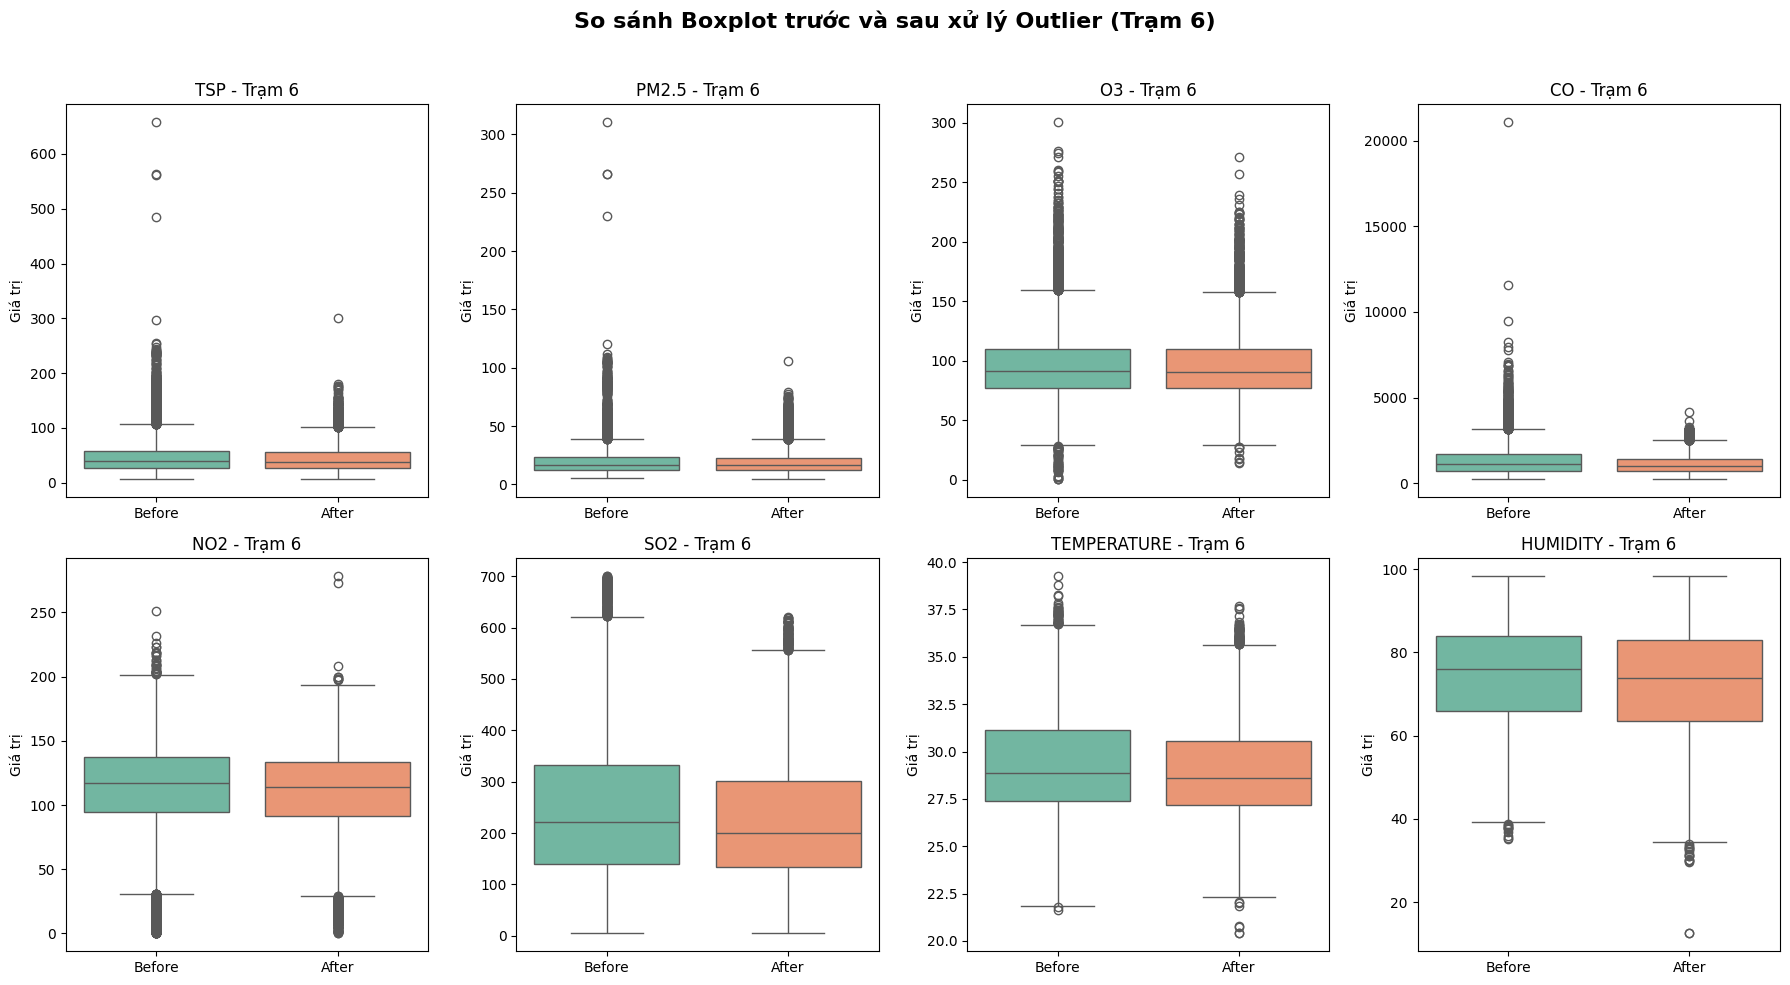

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Đọc file
st6_before = pd.read_excel("DataSetSt6Clean5.xlsx")     # Trước xử lý
st6_after = pd.read_excel("Station6_Cleaned.xlsx")      # Sau xử lý

#Reset index
st6_before_reset = st6_before.reset_index(drop=True)
st6_after_reset = st6_after.reset_index(drop=True)

#Định nghĩa các cột
quant_cols = ['tsp', 'pm2.5', 'o3', 'co', 'no2', 'so2', 'temperature', 'humidity']

#Vẽ box-plot so sánh trước và sau xử lý
plt.figure(figsize=(18, 10))

for i, col in enumerate(quant_cols, 1):
    plt.subplot(2, 4, i)

    # Gộp dữ liệu trước và sau xử lý
    merged = pd.concat([
        st6_before_reset[[col]].assign(Stage='Before'),
        st6_after_reset[[col]].assign(Stage='After')
    ], ignore_index=True)

    sns.boxplot(data=merged, x='Stage', y=col, palette='Set2')
    plt.title(f'{col.upper()} - Trạm 6', fontsize=12)
    plt.xlabel('')
    plt.ylabel('Giá trị')

plt.suptitle('So sánh Boxplot trước và sau xử lý Outlier (Trạm 6)', fontsize=16, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## ***4.5***

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

#Đọc file
file_name = "Station6_Cleaned.xlsx"
st6 = pd.read_excel(file_name)
print("Đọc file thành công! Kích thước dữ liệu:", st6.shape)
display(st6.head())

#Định nghĩa các cột
quant_cols = ['tsp', 'pm2.5', 'o3', 'co', 'no2', 'so2', 'temperature', 'humidity']

scaler = StandardScaler()

#Tạo DataFrame chứa các cột chuẩn hóa
st6_scaled_values = scaler.fit_transform(st6[quant_cols])
st6_scaled_df = pd.DataFrame(
    st6_scaled_values,
    columns=[col + '_scaled' for col in quant_cols]
)

#Gộp bảng chuẩn hóa vào dữ liệu gốc
st6_combined = pd.concat([st6, st6_scaled_df], axis=1)

#Lưu file
output_filename = "Station6_Scaled.xlsx"
st6_combined.to_excel(output_filename, index=False)
print("Đã tạo thêm cột chuẩn hóa và lưu thành công:", output_filename)

Đọc file thành công! Kích thước dữ liệu: (9499, 21)


,date,station no,tsp,pm2.5,co,temperature,humidity,so2,no2,o3,...,flag_iqr_pm2.5,flag_iqr_o3,flag_iqr_co,flag_iqr_no2,flag_iqr_so2,flag_iqr_temperature,flag_iqr_humidity,flag_iqr,iso_flag,is_outlier
0,2021-02-24 16:00:00,6,27.245455,14.381818,1243.4100,25.727273,62.800000,327.500000,92.474636,49.610364,...,False,False,False,False,False,False,False,False,1,False
1,2021-02-24 17:00:00,6,30.540000,15.220000,1155.1680,26.700000,62.100000,324.880000,106.897600,59.282600,...,False,False,False,False,False,False,False,False,1,False
2,2021-05-03 10:00:00,6,39.655667,18.690000,509.0532,28.425333,51.308333,268.637333,27.916333,26.703343,...,False,True,False,False,False,False,False,True,-1,True
3,2021-05-03 11:00:00,6,54.262667,25.498667,1027.0834,27.170333,57.241000,258.943333,55.907947,52.058760,...,False,True,False,False,False,False,False,True,-1,True
4,2021-05-03 14:00:00,6,29.471000,14.845667,785.0482,27.428667,56.618000,283.920667,53.128860,47.040023,...,False,True,True,True,False,False,False,True,-1,True


Đã tạo thêm cột chuẩn hóa và lưu thành công: Station6_Scaled.xlsx


## ***4.6***

In [ ]:
import pandas as pd
import numpy as np

#Đọc file
input_file = "Station6_Scaled.xlsx"
df = pd.read_excel(input_file)
print("Đọc file thành công! Kích thước dữ liệu:", df.shape)
display(df.head())

#Định nghĩa các cột
df.columns = df.columns.str.strip().str.lower().str.replace('\ufeff', '', regex=False)

#Danh sách chất sẽ tính AQI
pollutants = ['pm2.5', 'so2', 'no2', 'co', 'o3']
available_cols = [col for col in pollutants if col in df.columns]
print("Các cột có trong dữ liệu:", available_cols)

#Bảng mốc nồng độ (BP) và AQI (I)
BP = {
    'pm2.5': [0, 25, 50, 80, 150, 250, 350, 500],
    'so2':   [0, 125, 350, 550, 800, 1600, 2100, 2630],
    'no2':   [0, 100, 200, 700, 1200, 2350, 3100, 3850],
    'co':    [0, 10000, 30000, 45000, 60000, 90000, 120000, 150000],
    'o3':    [0, 160, 200, 300, 400, 800, 1000, 1200]
}

I = [0, 50, 100, 150, 200, 300, 400, 500]  # AQI mốc tương ứng

#Hàm tính AQI nội suy tuyến tính
def calc_aqi_substance(Cp, pollutant):
    if pd.isna(Cp) or Cp < 0:
        return np.nan

    bp = BP[pollutant]
    for i in range(len(bp) - 1):
        if bp[i] <= Cp <= bp[i + 1]:
            Il, Ih = I[i], I[i + 1]
            BPl, BPh = bp[i], bp[i + 1]
            Ia = (Ih - Il) / (BPh - BPl) * (Cp - BPl) + Il
            return round(Ia, 0)

    if Cp > bp[-1]:
        return 500
    return np.nan

#Tính AQI cho từng thông số
for p in available_cols:
    df[f'aqi_{p}'] = df[p].apply(lambda x: calc_aqi_substance(x, p))

#Tính AQI giờ tổng (AQI_h_total = max AQI thành phần)
df['aqi_h_total'] = df[[f'aqi_{p}' for p in available_cols]].max(axis=1)

#Lưu file
output_file = "Station6_AQI_Hourly.xlsx"
df.to_excel(output_file, index=False)

print("Đã tính AQI giờ & tổng hợp theo QĐ 1459/QĐ-TCMT!")
print("File đầu ra:", output_file)


Đọc file thành công! Kích thước dữ liệu: (9499, 29)


,date,station no,tsp,pm2.5,co,temperature,humidity,so2,no2,o3,...,iso_flag,is_outlier,tsp_scaled,pm2.5_scaled,o3_scaled,co_scaled,no2_scaled,so2_scaled,temperature_scaled,humidity_scaled
0,2021-02-24 16:00:00,6,27.245455,14.381818,1243.4100,25.727273,62.800000,327.500000,92.474636,49.610364,...,1,False,-0.720753,-0.498242,-1.673151,0.184904,-0.488234,0.839882,-1.257258,-0.716553
1,2021-02-24 17:00:00,6,30.540000,15.220000,1155.1680,26.700000,62.100000,324.880000,106.897600,59.282600,...,1,False,-0.584851,-0.411629,-1.326011,0.030340,-0.063099,0.817558,-0.879875,-0.769011
2,2021-05-03 10:00:00,6,39.655667,18.690000,509.0532,28.425333,51.308333,268.637333,27.916333,26.703343,...,-1,True,-0.208826,-0.053059,-2.495293,-1.101390,-2.391170,0.338332,-0.210508,-1.577736
3,2021-05-03 11:00:00,6,54.262667,25.498667,1027.0834,27.170333,57.241000,258.943333,55.907947,52.058760,...,-1,True,0.393721,0.650512,-1.585277,-0.194012,-1.566083,0.255732,-0.697402,-1.133143
4,2021-05-03 14:00:00,6,29.471000,14.845667,785.0482,27.428667,56.618000,283.920667,53.128860,47.040023,...,-1,True,-0.628948,-0.450311,-1.765402,-0.617959,-1.648000,0.468556,-0.597178,-1.179831


Các cột có trong dữ liệu: ['pm2.5', 'so2', 'no2', 'co', 'o3']
Đã tính AQI giờ & tổng hợp theo QĐ 1459/QĐ-TCMT!
File đầu ra: Station6_AQI_Hourly.xlsx


In [ ]:
import pandas as pd
import numpy as np

#Đọc file
input_file = "Station6_AQI_Hourly.xlsx"
df = pd.read_excel(input_file)
print("Đọc file thành công:", input_file)
print("Kích thước dữ liệu:", df.shape)

#Định nghĩa các cột
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['date_only'] = df['date'].dt.date

#Bảng mốc nồng độ (BP) và AQI (I)
BP = {
    'pm2.5': [0, 25, 50, 80, 150, 250, 350, 500],
    'so2':   [0, 125, 350, 550, 800, 1600, 2100, 2630],
    'no2':   [0, 100, 200, 700, 1200, 2350, 3100, 3850],
    'co':    [0, 10000, 30000, 45000, 60000, 90000, 120000, 150000],
    'o3':    [0, 160, 200, 300, 400, 800, 1000, 1200]
}
I = [0, 50, 100, 150, 200, 300, 400, 500]

def calc_aqi(Cp, pollutant):
    if pd.isna(Cp) or Cp < 0:
        return np.nan
    bp = BP[pollutant]
    for i in range(len(bp)-1):
        if bp[i] <= Cp <= bp[i+1]:
            return round((I[i+1]-I[i])/(bp[i+1]-bp[i])*(Cp-bp[i])+I[i], 0)
    if Cp > bp[-1]:
        return 500
    return np.nan

#Tính AQI ngày
cols = ['pm2.5', 'so2', 'no2', 'co', 'o3']
available_cols = [c for c in cols if c in df.columns]
print("Các thông số có trong dữ liệu:", available_cols)

daily_aqi = df.groupby('date_only')[available_cols].agg(['count', 'mean', 'max'])
daily_aqi.columns = ['_'.join(col).strip() for col in daily_aqi.columns.values]
daily_aqi.reset_index(inplace=True)

for col in available_cols:
    # PM2.5 → lấy trung bình ngày
    # Các chất khác → lấy giá trị lớn nhất trong ngày
    Cp_day = daily_aqi[f"{col}_mean"] if col == 'pm2.5' else daily_aqi[f"{col}_max"]

    # Chỉ tính nếu có >= 18 giờ dữ liệu hợp lệ
    valid = daily_aqi[f"{col}_count"] >= 18
    daily_aqi[f"aqi_{col}_day"] = np.where(valid, Cp_day.apply(lambda x: calc_aqi(x, col)), np.nan)

#AQI ngày tổng
aqi_day_cols = [f'aqi_{c}_day' for c in available_cols]
daily_aqi['aqi_daily_total'] = daily_aqi[aqi_day_cols].max(axis=1)

#Ghép với dữ liệu gốc
df = df.merge(
    daily_aqi[['date_only', 'aqi_daily_total'] + aqi_day_cols],
    on='date_only', how='left'
)

#Lưu file
output_name = "Station6_AQI_Daily.xlsx"
df.to_excel(output_name, index=False)
print("Đã tính AQI ngày và tổng hợp theo QĐ 1459/QĐ-TCMT!")
print("File đầu ra:", output_name)


Đọc file thành công: Station6_AQI_Hourly.xlsx
Kích thước dữ liệu: (9499, 35)
Các thông số có trong dữ liệu: ['pm2.5', 'so2', 'no2', 'co', 'o3']
Đã tính AQI ngày và tổng hợp theo QĐ 1459/QĐ-TCMT!
File đầu ra: Station6_AQI_Daily.xlsx


In [ ]:
#Đọc file
input_file = "Station6_AQI_Daily.xlsx"
df = pd.read_excel(input_file)
print("Đọc file thành công:", input_file)
print("Kích thước dữ liệu:", df.shape)

#Chuẩn hóa tên cột
df.columns = df.columns.str.strip().str.lower()

#Hàm xác định mùa theo tháng
def get_season(month):
    if 5 <= month <= 11:
        return 'Rainy'   # Mùa mưa: Tháng 5–11
    else:
        return 'Dry'     # Mùa khô: Tháng 12–4

#Thêm cột Season
df['Season'] = df['date'].dt.month.apply(get_season)

#Lưu file
output_file = "Station6_AQI_Daily_with_Season.xlsx"
df.to_excel(output_file, index=False)

print(f"Đã thêm cột 'Season' và lưu thành công -> {output_file}")

Đọc file thành công: Station6_AQI_Daily.xlsx
Kích thước dữ liệu: (9499, 42)
Đã thêm cột 'Season' và lưu thành công -> Station6_AQI_Daily_with_Season.xlsx


## ***Kiểm tra tương quan***

In [ ]:
import pandas as pd

# đọc lại file đã xuất ở cell trước
output_file = "Station6_AQI_Daily_with_Season.xlsx"
df_final = pd.read_excel(output_file)

# xem nhanh dữ liệu
print(" Đọc file thành công:", output_file)
print("Kích thước dữ liệu:", df_final.shape)
df_final.head()


 Đọc file thành công: Station6_AQI_Daily_with_Season.xlsx
Kích thước dữ liệu: (9499, 43)


,date,station no,tsp,pm2.5,co,temperature,humidity,so2,no2,o3,...,aqi_o3,aqi_h_total,date_only,aqi_daily_total,aqi_pm2.5_day,aqi_so2_day,aqi_no2_day,aqi_co_day,aqi_o3_day,Season
0,2021-02-24 16:00:00,6,27.245455,14.381818,1243.4100,25.727273,62.800000,327.500000,92.474636,49.610364,...,16.0,95,2021-02-24,NaN,NaN,NaN,NaN,NaN,NaN,Dry
1,2021-02-24 17:00:00,6,30.540000,15.220000,1155.1680,26.700000,62.100000,324.880000,106.897600,59.282600,...,19.0,94,2021-02-24,NaN,NaN,NaN,NaN,NaN,NaN,Dry
2,2021-05-03 10:00:00,6,39.655667,18.690000,509.0532,28.425333,51.308333,268.637333,27.916333,26.703343,...,8.0,82,2021-05-03,NaN,NaN,NaN,NaN,NaN,NaN,Rainy
3,2021-05-03 11:00:00,6,54.262667,25.498667,1027.0834,27.170333,57.241000,258.943333,55.907947,52.058760,...,16.0,80,2021-05-03,NaN,NaN,NaN,NaN,NaN,NaN,Rainy
4,2021-05-03 14:00:00,6,29.471000,14.845667,785.0482,27.428667,56.618000,283.920667,53.128860,47.040023,...,15.0,85,2021-05-03,NaN,NaN,NaN,NaN,NaN,NaN,Rainy


In [ ]:

# 4.7.1 CHUẨN BỊ — ultra-compact
import pandas as pd
from IPython.display import display

assert 'df_final' in globals(), "Chưa có df_final."

# SETTINGS (bật/tắt theo nhu cầu)
SHOW_NUMERIC_LIST = False   # True nếu muốn in toàn bộ tên cột số

# (1) OVERVIEW
n_rows, n_cols = df_final.shape
num_cols = df_final.select_dtypes(include='number').columns
date_span = ""
if 'date' in df_final.columns and pd.api.types.is_datetime64_any_dtype(df_final['date']):
    date_span = f" | date: {df_final['date'].min().date()}→{df_final['date'].max().date()}"
station_info = ""
for c in ['station', 'station no', 'station_no']:
    if c in df_final.columns:
        station_info = f" | stations={df_final[c].nunique(dropna=True)}"; break
print(f"[OVERVIEW] rows={n_rows} | cols={n_cols} | numeric={len(num_cols)}{date_span}{station_info}")  # giải thích: tóm tắt nhanh

# (2)  DANH SÁCH CỘT SỐ
if SHOW_NUMERIC_LIST:
    print("[NUMERIC COLS]", list(num_cols))  # giải thích: chỉ in khi cần

# (3) NA SUMMARY (chỉ cột số, chỉ hiện cột có NA)
na = df_final[num_cols].isna().sum()
na = na[na > 0].sort_values(ascending=False)  # giải thích: lọc cột có NA > 0
if na.empty:
    print("[NA SUMMARY] Không có NA ở các cột số.")
    na_summary = pd.DataFrame(columns=['variable','na_count','na_pct'])
else:
    na_summary = (na.to_frame('na_count')
                    .assign(na_pct=lambda d: (d['na_count']/n_rows*100).round(2))
                    .reset_index().rename(columns={'index':'variable'}))
    print("[NA SUMMARY] (only NA>0)")
    display(na_summary)

# (4) DATAFRAME DÙNG CHO TƯƠNG QUAN
df_num = df_final[num_cols]   # giải thích: giữ nguyên NA; 4.7.2 dùng pairwise complete
print(f"[df_num] shape={df_num.shape}")
display(df_num.head(2))













[OVERVIEW] rows=9499 | cols=43 | numeric=30 | date: 2021-01-04→2022-12-06 | stations=1
[NA SUMMARY] (only NA>0)


,variable,na_count,na_pct
0,aqi_no2_day,695,7.32
1,aqi_o3_day,695,7.32
2,aqi_co_day,695,7.32
3,aqi_so2_day,695,7.32
4,aqi_pm2.5_day,695,7.32
5,aqi_daily_total,695,7.32
6,no2,3,0.03
7,aqi_no2,3,0.03
8,no2_scaled,3,0.03
9,aqi_so2,1,0.01


[df_num] shape=(9499, 30)


,station no,tsp,pm2.5,co,temperature,humidity,so2,no2,o3,iso_flag,...,aqi_no2,aqi_co,aqi_o3,aqi_h_total,aqi_daily_total,aqi_pm2.5_day,aqi_so2_day,aqi_no2_day,aqi_co_day,aqi_o3_day
0,6,27.245455,14.381818,1243.410,25.727273,62.8,327.50,92.474636,49.610364,1,...,46.0,6,16.0,95,NaN,NaN,NaN,NaN,NaN,NaN
1,6,30.540000,15.220000,1155.168,26.700000,62.1,324.88,106.897600,59.282600,1,...,53.0,6,19.0,94,NaN,NaN,NaN,NaN,NaN,NaN


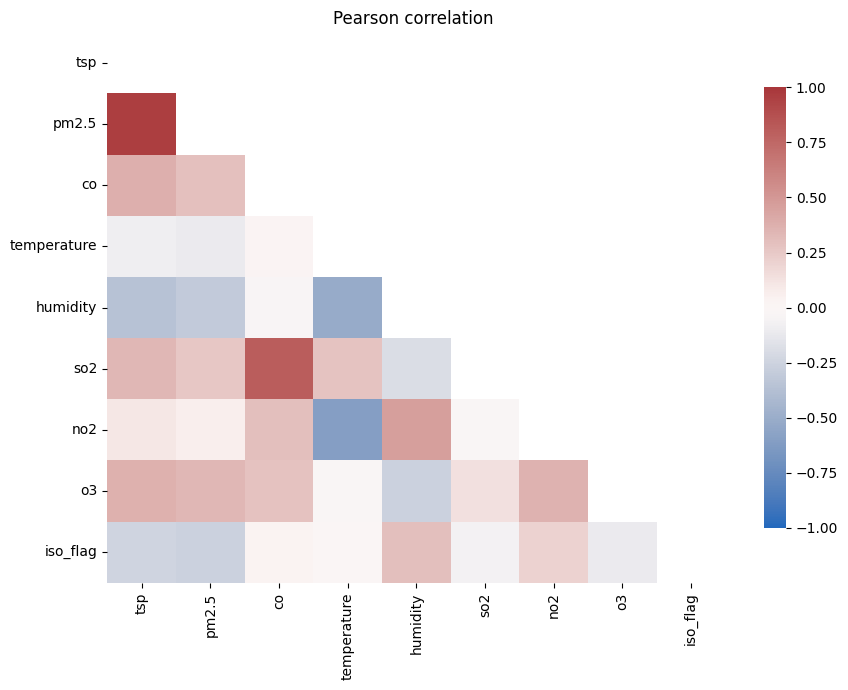

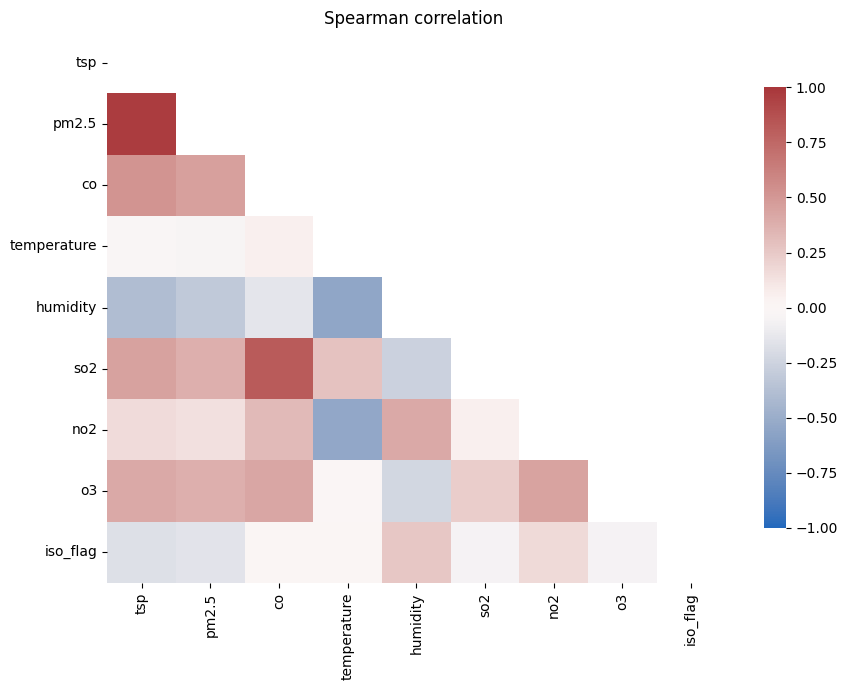

In [ ]:

# 4.7.2 — HEATMAP
import numpy as np, matplotlib.pyplot as plt, seaborn as sns

# 1) Lọc cột (KHÔNG dùng regex để tránh sai độ dài mask)
tmp = df_num.drop(columns=['station no'], errors='ignore')
keep = (~tmp.columns.str.startswith('aqi')) & (~tmp.columns.str.endswith('_scaled'))
df_num = tmp.loc[:, keep]

# 2) Ma trận tương quan
corr_p = df_num.corr(method='pearson',  min_periods=2)
corr_s = df_num.corr(method='spearman', min_periods=2)

# 3) Vẽ tam giác dưới
def plot_lower_triangle(corr, title):
    mask = np.triu(np.ones_like(corr, dtype=bool))
    plt.figure(figsize=(9, 7))
    sns.heatmap(corr, mask=mask, vmin=-1, vmax=1, cmap='vlag', center=0,
                cbar_kws={'shrink':0.8})
    plt.title(title, fontsize=12); plt.tight_layout(); plt.show()

plot_lower_triangle(corr_p, "Pearson correlation ")
plot_lower_triangle(corr_s, "Spearman correlation ")










In [ ]:
## 4.7.3 — High-corr pairs (|r| ≥ THR) dựa trên corr_p/corr_s ở 4.7.2

THR = 0.80
SHOW_PVAL_N = False   # True nếu muốn kèm p-value và n

# lấy cặp từ tam giác trên của corr_p
cols = corr_p.columns.to_list()
M_p  = corr_p.values
M_s  = corr_s.values
iu, ju = np.triu_indices(len(cols), k=1)
sel = np.abs(M_p[iu, ju]) >= THR
iu, ju = iu[sel], ju[sel]

rows = []
if SHOW_PVAL_N:
    from scipy.stats import pearsonr  # import cục bộ khi cần
    for i, j in zip(iu, ju):
        a, b = cols[i], cols[j]
        ab = df_num[[a, b]].dropna()
        if len(ab) >= 3:
            rp, pp = pearsonr(ab[a], ab[b])
            rows.append([a, b, rp, M_s[i, j], pp, len(ab)])
    pairs = pd.DataFrame(rows, columns=['var1','var2','r_pearson','r_spearman','p_pearson','n'])
else:
    for i, j in zip(iu, ju):
        rows.append([cols[i], cols[j], M_p[i, j], M_s[i, j], abs(M_p[i, j])])
    pairs = pd.DataFrame(rows, columns=['var1','var2','r_pearson','r_spearman','abs_r']) \
              .sort_values('abs_r', ascending=False).drop(columns='abs_r')

print(f"[HIGH-CORR] số cặp |r| ≥ {THR}: {len(pairs)}")
display(pairs.reset_index(drop=True).round(3).head(30))  # hiển thị ngắn gọn; bỏ .head(30) nếu muốn xem hết





[HIGH-CORR] số cặp |r| ≥ 0.8: 2


,var1,var2,r_pearson,r_spearman
0,tsp,pm2.5,0.962,0.971
1,co,so2,0.807,0.813


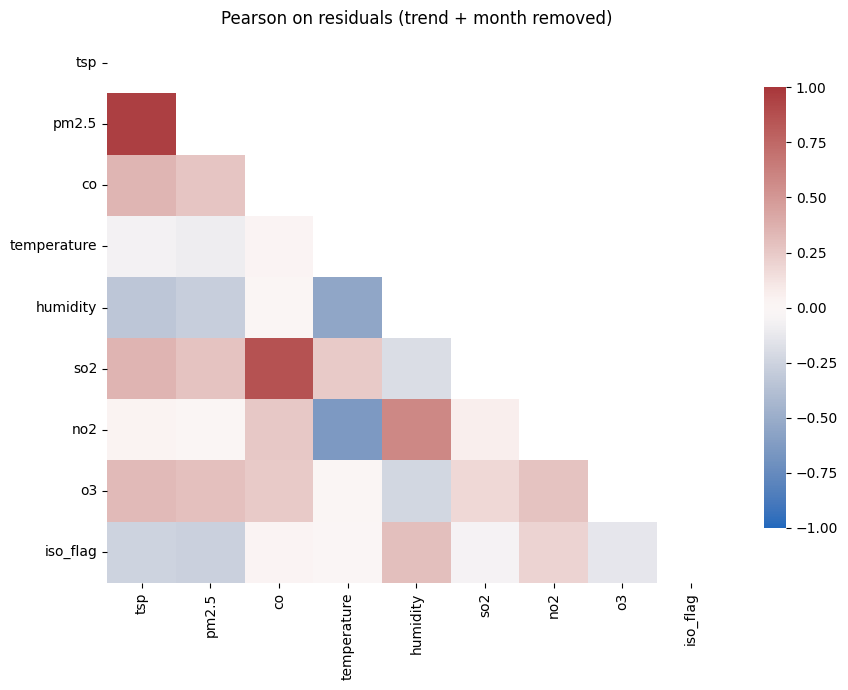

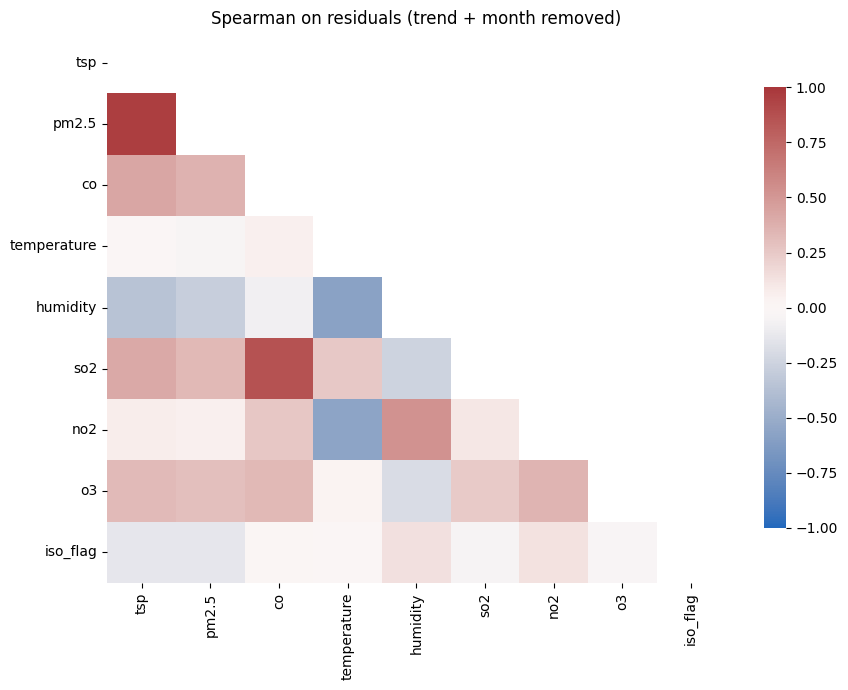

[SUMMARY] |r| ≥ 0.8: TRƯỚC=2  |  SAU=2
[VẪN ≥ THR SAU KHỬ] (ưu tiên xử lý/giữ 1 đại diện nếu cần)


,var1,var2,r_after,r_before,delta
0,tsp,pm2.5,0.96,0.962,-0.002
1,co,so2,0.86,0.807,0.053


[TOP GIẢM MẠNH SAU KHỬ] 


,var1,var2,r_before,r_after,delta
0,no2,o3,0.366,0.277,-0.089
1,tsp,no2,0.106,0.036,-0.070
2,pm2.5,no2,0.070,0.007,-0.062
3,tsp,o3,0.373,0.326,-0.047
4,co,o3,0.289,0.244,-0.045
5,pm2.5,o3,0.339,0.297,-0.042
6,co,no2,0.298,0.257,-0.041
7,co,humidity,-0.035,0.002,-0.033
8,tsp,humidity,-0.364,-0.332,-0.032
9,humidity,o3,-0.265,-0.233,-0.032


In [ ]:
# 4.7.4 — Residualized correlation
#  loại ảnh hưởng "tháng" (seasonality) + "trend tuyến tính theo thời gian" khỏi từng biến X,
#  tính tương quan X–X để tránh "giả tương quan" do cùng mùa.

import numpy as np, pandas as pd

# Kiểm tra đầu vào bắt buộc
assert 'df_final' in globals() and 'df_num' in globals(), "Thiếu df_final/df_num. Hãy chạy 4.7.1–4.7.2."
assert 'date' in df_final.columns, "Thiếu cột 'date' trong df_final."
if not pd.api.types.is_datetime64_any_dtype(df_final['date']):
    df_final['date'] = pd.to_datetime(df_final['date'], errors='coerce')  # # giải thích: đảm bảo date là datetime

# Hàm khử mùa & trend cho 1 biến
def residualize_series(y: pd.Series, dates: pd.Series) -> pd.Series:
    """
    y ~ const + trend(t) + month dummies  --> lấy phần dư (residual).
    - const: hệ số chệch
    - trend: chỉ số thời gian tuyến tính (0,1,2,...)
    - month dummies: 11 biến giả cho tháng (drop_first=True)
    """
    idx = y.notna() & dates.notna()
    if idx.sum() < 8:  # # giải thích: quá ít quan sát để khử mùa/trend
        return pd.Series(index=y.index, dtype='float64')

    t = np.arange(idx.sum(), dtype='float64')                      # # giải thích: trend tuyến tính
    mon = dates.loc[idx].dt.month.astype('int16')
    M = pd.get_dummies(mon, prefix='m', drop_first=True)           # # giải thích: 11 dummy cho tháng
    X = np.column_stack([np.ones(idx.sum()), t, M.values])         # # giải thích: thiết kế [const, trend, dummies]
    yv = y.loc[idx].astype('float64').values

    beta, *_ = np.linalg.lstsq(X, yv, rcond=None)                  # # giải thích: OLS gọn bằng lstsq
    resid = yv - (X @ beta)
    out = pd.Series(resid, index=y.index[idx])                     # # giải thích: trả về residual đúng index gốc
    return out.reindex(y.index)

# Tạo residuals cho toàn bộ cột X
dates = df_final.loc[df_num.index, 'date']
res_df = pd.DataFrame({col: residualize_series(df_num[col], dates) for col in df_num.columns})

#  Ma trận tương quan SAU khi khử mùa/trend
corr_p_res = res_df.corr(method='pearson',  min_periods=2)  # Pearson (tuyến tính)
corr_s_res = res_df.corr(method='spearman', min_periods=2)  # Spearman (đơn điệu, chống ngoại lai)

# VẼ HEATMAP (tam giác dưới)
# Ghi chú: Giữ cùng style như 4.7.2 để so sánh trực quan "trước vs sau"
def plot_lower_triangle(corr, title):
    import matplotlib.pyplot as plt, seaborn as sns
    mask = np.triu(np.ones_like(corr, dtype=bool))               # # giải thích: ẩn tam giác trên (ma trận đối xứng)
    plt.figure(figsize=(9, 7))
    sns.heatmap(corr, mask=mask, vmin=-1, vmax=1, cmap='vlag', center=0,
                cbar_kws={'shrink':0.8})
    plt.title(title, fontsize=12)
    plt.tight_layout(); plt.show()

plot_lower_triangle(corr_p_res, "Pearson on residuals (trend + month removed)")
plot_lower_triangle(corr_s_res, "Spearman on residuals (trend + month removed)")

# TÓM TẮT NGẮN CHO BÁO CÁO (so sánh TRƯỚC/Sau)
# so với corr_p (trước khử), đếm số cặp |r| ≥ THR
THR = 0.80  # # giải thích: ngưỡng "rất cao" dùng ở 4.7.3
cols = df_num.columns.to_list()
M0 = df_num.corr(method='pearson', min_periods=2).values         # trước khử (dùng lại quy tắc 4.7.2)
M1 = corr_p_res.values                                           # sau khử
iu, ju = np.triu_indices(len(cols), k=1)
n_high_before = int((np.abs(M0[iu, ju]) >= THR).sum())
n_high_after  = int((np.abs(M1[iu, ju]) >= THR).sum())
print(f"[SUMMARY] |r| ≥ {THR}: TRƯỚC={n_high_before}  |  SAU={n_high_after}")

# DANH SÁCH "VẪN CAO SAU KHỬ"
stay_sel = (np.abs(M1[iu, ju]) >= THR)
pairs_after = pd.DataFrame({
    'var1': [cols[i] for i in iu[stay_sel]],
    'var2': [cols[j] for j in ju[stay_sel]],
    'r_after':  M1[iu[stay_sel], ju[stay_sel]],
    'r_before': M0[iu[stay_sel], ju[stay_sel]],
}).assign(delta=lambda d: d.r_after.abs() - d.r_before.abs()
).sort_values('r_after', ascending=False).reset_index(drop=True)

print("[VẪN ≥ THR SAU KHỬ] (ưu tiên xử lý/giữ 1 đại diện nếu cần)")
display(pairs_after.round(3).head(20))
#  (Tuỳ chọn) TOP CẶP GIẢM MẠNH SAU KHỬ (để nêu 'giả tương quan' do mùa vụ)
diff = (np.abs(M1[iu, ju]) - np.abs(M0[iu, ju]))
drop_idx = np.argsort(diff)[:10]  # giá trị âm lớn nhất -> giảm mạnh nhất
drops = pd.DataFrame({
    'var1': [cols[iu[k]] for k in drop_idx],
    'var2': [cols[ju[k]] for k in drop_idx],
    'r_before': M0[iu[drop_idx], ju[drop_idx]],
    'r_after':  M1[iu[drop_idx], ju[drop_idx]],
}).assign(delta=lambda d: d.r_after.abs() - d.r_before.abs()
).sort_values('delta')  # âm nhiều = giảm mạnh
print("[TOP GIẢM MẠNH SAU KHỬ] ")
display(drops.round(3))





In [ ]:
# 4.7.5 — VIF & Condition Index (compact)

import numpy as np, pandas as pd

# dữ liệu đầu vào cho VIF/CI (nếu cần chỉ định subset, đổi X0 = df_num[cols])
X0 = df_num.copy()
X = X0.dropna()
cols = X.columns.tolist()
print(f"[INFO] VIF/CI trên {len(cols)} biến, n={len(X)} hàng hoàn chỉnh")

# VIF
from numpy.linalg import lstsq
def vif_df(M: pd.DataFrame) -> pd.DataFrame:
    A = M.values.astype('float64'); out=[]
    for j in range(A.shape[1]):
        y = A[:, j]
        Xj = np.delete(A, j, axis=1)
        Xj = np.column_stack([np.ones(len(Xj)), Xj])
        b, *_ = lstsq(Xj, y, rcond=None)
        yhat = Xj @ b
        ss_res = np.sum((y - yhat)**2)
        ss_tot = np.sum((y - y.mean())**2)
        r2 = 0.0 if ss_tot==0 else 1 - ss_res/ss_tot
        vif = np.inf if (1 - r2) <= 1e-12 else 1/(1 - r2)
        out.append((cols[j], vif, r2))
    return pd.DataFrame(out, columns=['variable','VIF','R2']).sort_values('VIF', ascending=False)

vif_tbl = vif_df(X)
print("\n=== VIF ( >5 cảnh báo, >10 nghiêm trọng ) ===")
display(vif_tbl.round(3))

# Condition Index (Belsley)
Z = (X - X.mean()) / X.std(ddof=0)
R = np.corrcoef(Z.fillna(0.0).T)
eig = np.real(np.linalg.eigvals(R))
ci = np.sqrt(eig.max() / np.clip(eig, 1e-12, None))
ci_tbl = pd.DataFrame({'Eigenvalue': eig, 'ConditionIndex': ci}).sort_values('ConditionIndex')
print("\n=== Condition Index ( >30 nghiêm trọng; 15–30 lưu ý ) ===")
display(ci_tbl.round({'Eigenvalue':4,'ConditionIndex':2}))

print(f"[SUMMARY] CI_max={ci_tbl['ConditionIndex'].max():.2f} | VIF_max={vif_tbl['VIF'].replace(np.inf, np.nan).max():.2f}")


[INFO] VIF/CI trên 9 biến, n=9495 hàng hoàn chỉnh

=== VIF ( >5 cảnh báo, >10 nghiêm trọng ) ===


,variable,VIF,R2
0,tsp,17.939,0.944
1,pm2.5,15.840,0.937
2,co,4.221,0.763
5,so2,3.944,0.746
6,no2,3.017,0.669
4,humidity,2.460,0.594
3,temperature,2.397,0.583
7,o3,1.758,0.431
8,iso_flag,1.245,0.197



=== Condition Index ( >30 nghiêm trọng; 15–30 lưu ý ) ===


,Eigenvalue,ConditionIndex
0,2.9699,1.00
1,2.1643,1.17
2,1.4855,1.41
3,0.9126,1.80
4,0.7848,1.95
6,0.3051,3.12
7,0.2172,3.70
8,0.1307,4.77
5,0.0299,9.97


[SUMMARY] CI_max=9.97 | VIF_max=17.94
